## Hyperparameters to tune

- Tune hidden layer sizes using candidate tuples, ie. (128, 128), (64, 64, 64) etc.
- Dropout (constant across layers)
- Learning rate
- Batch size

Using 320 shots to run as a good middle ground
params chosen with fidelity loss

Don't tune epochs
Instead measure the loss and show the converging loss curve across the epochs in the report and as justification for how many epochs to use
(Use a large max epoch and stop early if reaches a constraint)

For each hyperparameter, justify through literature why it's valid but for the specific value taken, being chosen empirically through optimisation is defensible.

In [9]:
import numpy as np
import QST_core_processes as qst
import pickle
import os
data_train = np.load("data/hyperparam_tuning_set_train.npz", allow_pickle=True)
data_val = np.load("data/hyperparam_tuning_set_test.npz", allow_pickle=True)

In [10]:
# Lists stored for future analysis/ graphing of parameter space
hidden_layers = []
dropouts = []
learning_rates = []
batch_sizes = []

final_losses = []
best_losses = []

In [11]:
hidden_size_candidates = [
    (128, 128),            # 2 layers
    (256, 256),            # 2 layers wide
    (256, 128, 64),        # 3 layers tapered
    (256, 256, 128),       # 3 layers wide
    (256, 256, 128, 64),   # 4 layers
]

dropout_candidates = [0.0, 0.1, 0.2]
learning_rate_candidates = [1e-3, 5e-4, 1e-4]
batch_size_candidates = [64, 128, 256]

In [ ]:
results = []
path = "hyperparam_results.pkl"
run = 1
runs = len(hidden_size_candidates) * len(dropout_candidates) * len(learning_rate_candidates) * len(batch_size_candidates)

if os.path.exists(path):
    with open(path, "rb") as f:
        results = pickle.load(f)

for hidden_size in hidden_size_candidates:
    for dropout in dropout_candidates:
        for learning_rate in learning_rate_candidates:
            for batch_size in batch_size_candidates:
                print(f"Run {run} out of {runs}: Training with hidden_size={hidden_size}, dropout={dropout}, learning_rate={learning_rate}, batch_size={batch_size}")
                run += 1
                model = qst.NN_Builder(
                    n_qubits=2,
                    model_type="mlp",
                    loss_type="fidelity",
                    target="tau",
                    hidden_sizes=hidden_size,
                    dropout=dropout,
                    lr=learning_rate,
                    batch_size=batch_size,
                    epochs=100
                )

                history, _ = model.fit_and_predict(data_train, data_val)
                final_loss = history["loss"][-1]
                best_loss = min(history["loss"])

                result = {
                    "hidden_size": hidden_size,
                    "dropout": dropout,
                    "learning_rate": learning_rate,
                    "batch_size": batch_size,
                    "final_loss": final_loss,
                    "best_loss": best_loss
                }
                results.append(result)

                # with open(path, "wb") as f:
                #     pickle.dump(results, f)
                ### Commented to avoid overwriting

Run 1 out of 135: Training with hidden_size=(128, 128), dropout=0.0, learning_rate=0.001, batch_size=64
Run 2 out of 135: Training with hidden_size=(128, 128), dropout=0.0, learning_rate=0.001, batch_size=128
Run 3 out of 135: Training with hidden_size=(128, 128), dropout=0.0, learning_rate=0.001, batch_size=256
Run 4 out of 135: Training with hidden_size=(128, 128), dropout=0.0, learning_rate=0.0005, batch_size=64
Run 5 out of 135: Training with hidden_size=(128, 128), dropout=0.0, learning_rate=0.0005, batch_size=128
Run 6 out of 135: Training with hidden_size=(128, 128), dropout=0.0, learning_rate=0.0005, batch_size=256
Run 7 out of 135: Training with hidden_size=(128, 128), dropout=0.0, learning_rate=0.0001, batch_size=64
Run 8 out of 135: Training with hidden_size=(128, 128), dropout=0.0, learning_rate=0.0001, batch_size=128
Run 9 out of 135: Training with hidden_size=(128, 128), dropout=0.0, learning_rate=0.0001, batch_size=256
Run 10 out of 135: Training with hidden_size=(128, 1

## For final best chosen model, record again and use that epoch loss curve to show not under or overfitting

**Mention in report that doing a broad parameter search first, then narrowing search around promising param space, common method**

In [34]:
import pandas as pd

with open(path, "rb") as f:
    results = pickle.load(f)

df = pd.DataFrame(results)
df = df.sort_values(by="final_loss")

In [ ]:
# Extract unconverged runs and redo with 200 epochs

config_cols = ["hidden_size", "dropout", "learning_rate", "batch_size"]

rerun_df = df[df["final_loss"] == df["best_loss"]][config_cols].drop_duplicates()

configs_to_rerun = list(rerun_df.itertuples(index=False, name=None))

run = 1
for hidden_size, dropout, learning_rate, batch_size in configs_to_rerun:
    print(f"Rerun {run} out of {len(configs_to_rerun)}: Rerunning with hidden_size={hidden_size}, dropout={dropout}, learning_rate={learning_rate}, batch_size={batch_size}")
    run += 1
    model = qst.NN_Builder(
        n_qubits=2,
        model_type="mlp",
        loss_type="fidelity",
        target="tau",
        hidden_sizes=hidden_size,
        dropout=dropout,
        lr=learning_rate,
        batch_size=batch_size,
        epochs=200
    )

    history, _ = model.fit_and_predict(data_train, data_val)
    final_loss = history["loss"][-1]
    best_loss = min(history["loss"])

    result = {
        "hidden_size": hidden_size,
        "dropout": dropout,
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "final_loss": final_loss,
        "best_loss": best_loss
    }
    results.append(result)

    # with open(path, "wb") as f:
    #     pickle.dump(results, f)

Rerun 1 out of 46: Rerunning with hidden_size=(256, 256), dropout=0.2, learning_rate=0.0005, batch_size=64
Rerun 2 out of 46: Rerunning with hidden_size=(256, 256), dropout=0.1, learning_rate=0.0005, batch_size=128
Rerun 3 out of 46: Rerunning with hidden_size=(256, 256), dropout=0.1, learning_rate=0.0005, batch_size=256
Rerun 4 out of 46: Rerunning with hidden_size=(256, 256), dropout=0.2, learning_rate=0.0005, batch_size=256
Rerun 5 out of 46: Rerunning with hidden_size=(256, 256, 128), dropout=0.2, learning_rate=0.0005, batch_size=256
Rerun 6 out of 46: Rerunning with hidden_size=(256, 256, 128), dropout=0.1, learning_rate=0.0001, batch_size=64
Rerun 7 out of 46: Rerunning with hidden_size=(256, 128, 64), dropout=0.1, learning_rate=0.001, batch_size=128
Rerun 8 out of 46: Rerunning with hidden_size=(256, 256), dropout=0.2, learning_rate=0.0001, batch_size=64
Rerun 9 out of 46: Rerunning with hidden_size=(256, 256), dropout=0.1, learning_rate=0.0001, batch_size=64
Rerun 10 out of 46:

## Go from here onwards in order to not rewrite results!!! Rerunning ones that didnt converge with more epochs for fairer testing, and removing initial
#### Once this is done - we will ascertain best params and run on a more localised set of candidates

In [64]:
config_cols = ["hidden_size", "dropout", "learning_rate", "batch_size"]

with open('hyperparam_results.pkl', "rb") as f:
    results = pickle.load(f)

df = pd.DataFrame(results)
df = df.sort_index().drop_duplicates(subset=config_cols, keep="last").reset_index(drop=True)

In [65]:
df[df["final_loss"] == df['best_loss']].shape

(5, 6)

In [66]:
df.sort_values(by="best_loss").head(10)

,hidden_size,dropout,learning_rate,batch_size,final_loss,best_loss
94,"(256, 256, 128)",0.1,0.0001,64,0.059360,0.058878
62,"(256, 256, 128)",0.1,0.0005,64,0.060240,0.059088
59,"(256, 256, 128)",0.1,0.0010,64,0.059750,0.059154
63,"(256, 256, 128)",0.1,0.0005,128,0.060103,0.059246
93,"(256, 256, 128)",0.2,0.0005,256,0.059912,0.059497
89,"(256, 256)",0.2,0.0005,64,0.060100,0.059505
92,"(256, 256)",0.2,0.0005,256,0.061274,0.059551
60,"(256, 256, 128)",0.1,0.0010,128,0.061285,0.059571
61,"(256, 256, 128)",0.1,0.0010,256,0.059925,0.059879
99,"(256, 256, 128)",0.1,0.0001,128,0.060419,0.060179


In [67]:
df.groupby('learning_rate')['best_loss'].mean()

learning_rate
0.0001    0.079971
0.0005    0.069857
0.0010    0.067057
Name: best_loss, dtype: float64

In [68]:
hidden_size_local = [
    (128, 192, 128),
    (128, 256, 128),
    (192, 256, 128),
    (256, 256, 128),
    (256, 192, 128),
    (256, 256, 256)
]
dropouts_local = [0.05, 0.075, 0.1, 0.125, 0.15]
batch_size_local = [48, 64, 80]

Learning rate has minimal effect, and just balances with epochs. Defnesible to use 5e-4 lr and 150 epochs to find less expensive middle ground
"Preliminary experiments showed that a learning rate of 10e-4 required substantially more epochs to converge, with limited improvement in validation loss, while 10e-3 converged more rapidly but was more aggressive. A value of 5e-4 with 150 epochs was therefore selected as a compromise between convergence quality and computational cost."
Show lr balancing with epochs to not under or overfit
Now searching in 3 hidden layers, around 0.1 dropout, and around 64 batch size

In [ ]:
results = []
path_local = "hyperparam_results_local.pkl"
run = 1
runs = len(hidden_size_local) * len(dropouts_local) * len(batch_size_local)

if os.path.exists(path_local):
    with open(path_local, "rb") as f:
        results = pickle.load(f)

for hidden_size in hidden_size_local:
    for dropout in dropouts_local:
        for batch_size in batch_size_local:
            print(f"Run {run} out of {runs}: Training with hidden_size={hidden_size}, dropout={dropout}, learning_rate={learning_rate}, batch_size={batch_size}")
            run += 1
            model = qst.NN_Builder(
                n_qubits=2,
                model_type="mlp",
                loss_type="fidelity",
                target="tau",
                hidden_sizes=hidden_size,
                dropout=dropout,
                lr=5e-4,
                batch_size=batch_size,
                epochs=150
            )

            history, _ = model.fit_and_predict(data_train, data_val)
            final_loss = history["loss"][-1]
            best_loss = min(history["loss"])

            result = {
                "hidden_size": hidden_size,
                "dropout": dropout,
                "learning_rate": 5e-4,
                "batch_size": batch_size,
                "final_loss": final_loss,
                "best_loss": best_loss
            }
            results.append(result)

            # with open(path_local, "wb") as f:
            #     pickle.dump(results, f)
            ## Commented to avoid overwriting

Run 1 out of 90: Training with hidden_size=(128, 192, 128), dropout=0.05, learning_rate=0.0001, batch_size=48
Run 2 out of 90: Training with hidden_size=(128, 192, 128), dropout=0.05, learning_rate=0.0001, batch_size=64
Run 3 out of 90: Training with hidden_size=(128, 192, 128), dropout=0.05, learning_rate=0.0001, batch_size=80
Run 4 out of 90: Training with hidden_size=(128, 192, 128), dropout=0.075, learning_rate=0.0001, batch_size=48
Run 5 out of 90: Training with hidden_size=(128, 192, 128), dropout=0.075, learning_rate=0.0001, batch_size=64
Run 6 out of 90: Training with hidden_size=(128, 192, 128), dropout=0.075, learning_rate=0.0001, batch_size=80
Run 7 out of 90: Training with hidden_size=(128, 192, 128), dropout=0.1, learning_rate=0.0001, batch_size=48
Run 8 out of 90: Training with hidden_size=(128, 192, 128), dropout=0.1, learning_rate=0.0001, batch_size=64
Run 9 out of 90: Training with hidden_size=(128, 192, 128), dropout=0.1, learning_rate=0.0001, batch_size=80
Run 10 out

If outputs give (256,256,256) as best layer structure, then can retest on more nodes.

## All data finally collected now.

In [74]:
config_cols = ["hidden_size", "dropout", "learning_rate", "batch_size"]

with open('hyperparam_results.pkl', "rb") as f:
    results = pickle.load(f)

df1 = pd.DataFrame(results)

with open('hyperparam_results_local.pkl', "rb") as f:
    results_local = pickle.load(f)

df2 = pd.DataFrame(results_local)

# df = pd.concat([df1, df2], ignore_index=True).drop_duplicates(subset=config_cols, keep="last").sort_values(by="best_loss").reset_index(drop=True)
df = df2.sort_values(by="best_loss").reset_index(drop=True)
df.head(10)

,hidden_size,dropout,learning_rate,batch_size,final_loss,best_loss
0,"(256, 256, 256)",0.150,0.0005,80,0.056209,0.056207
1,"(256, 256, 256)",0.125,0.0005,80,0.057448,0.056295
2,"(256, 256, 256)",0.125,0.0005,48,0.057394,0.056552
3,"(256, 256, 256)",0.150,0.0005,64,0.057324,0.056750
4,"(256, 256, 256)",0.150,0.0005,48,0.058399,0.057048
5,"(256, 256, 256)",0.100,0.0005,64,0.058098,0.057095
6,"(256, 256, 256)",0.100,0.0005,48,0.058903,0.057194
7,"(256, 256, 256)",0.100,0.0005,80,0.057766,0.057194
8,"(256, 256, 256)",0.125,0.0005,64,0.057265,0.057265
9,"(256, 256, 256)",0.075,0.0005,48,0.058449,0.057365


In [75]:
df.groupby('hidden_size')['best_loss'].mean()

hidden_size
(128, 192, 128)    0.061571
(128, 256, 128)    0.060872
(192, 256, 128)    0.059439
(256, 192, 128)    0.058831
(256, 256, 128)    0.058705
(256, 256, 256)    0.057372
Name: best_loss, dtype: float64

In [76]:
df.groupby('batch_size')['best_loss'].mean()

batch_size
48    0.059374
64    0.059510
80    0.059511
Name: best_loss, dtype: float64

In [77]:
df.groupby('dropout')['best_loss'].mean()

dropout
0.050    0.059658
0.075    0.059175
0.100    0.059239
0.125    0.059379
0.150    0.059873
Name: best_loss, dtype: float64

## Results
#### Can say (256, 256, 256), dropout of 8%, batch size of 64 are significant as the best parameters

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

config_cols = ["hidden_size", "dropout", "learning_rate", "batch_size"]

with open("hyperparam_results.pkl", "rb") as f:
    results = pickle.load(f)
df1 = pd.DataFrame(results).drop_duplicates(subset=config_cols, keep="last").sort_values(by="best_loss").reset_index(drop=True)

with open("hyperparam_results_local.pkl", "rb") as f:
    results_local = pickle.load(f)
df2 = pd.DataFrame(results_local)

# Optional combined dataframe if you want all explored points together
df_all = (
    pd.concat([df1, df2], ignore_index=True)
    .drop_duplicates(subset=config_cols, keep="last")
    .sort_values(by="best_loss")
    .reset_index(drop=True)
)

print("Broad search shape:", df1.shape)
print("Local search shape:", df2.shape)
print("Combined shape:", df_all.shape)

df_all.head(10)

Broad search shape: (135, 6)
Local search shape: (90, 6)
Combined shape: (224, 6)


,hidden_size,dropout,learning_rate,batch_size,final_loss,best_loss
0,"(256, 256, 256)",0.150,0.0005,80,0.056209,0.056207
1,"(256, 256, 256)",0.125,0.0005,80,0.057448,0.056295
2,"(256, 256, 256)",0.125,0.0005,48,0.057394,0.056552
3,"(256, 256, 256)",0.150,0.0005,64,0.057324,0.056750
4,"(256, 256, 256)",0.150,0.0005,48,0.058399,0.057048
5,"(256, 256, 256)",0.100,0.0005,64,0.058098,0.057095
6,"(256, 256, 256)",0.100,0.0005,48,0.058903,0.057194
7,"(256, 256, 256)",0.100,0.0005,80,0.057766,0.057194
8,"(256, 256, 256)",0.125,0.0005,64,0.057265,0.057265
9,"(256, 256, 256)",0.075,0.0005,48,0.058449,0.057365


In [84]:
def make_labels(df):
    df = df.copy()
    df["hidden_label"] = df["hidden_size"].apply(lambda x: str(tuple(x)) if not isinstance(x, str) else x)
    return df

df1_plot = make_labels(df1)
df2_plot = make_labels(df2)
df_all_plot = make_labels(df_all)

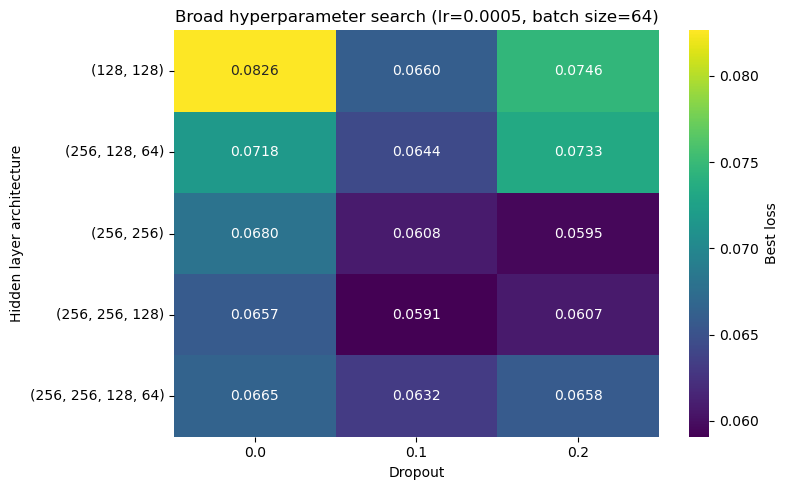

In [85]:
best_lr = 5e-4
best_bs = 64

df1_slice = df1_plot[
    (df1_plot["learning_rate"] == best_lr) &
    (df1_plot["batch_size"] == best_bs)
]

pivot1 = df1_slice.pivot_table(
    values="best_loss",
    index="hidden_label",
    columns="dropout",
    aggfunc="min"
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot1,
    annot=True,
    fmt=".4f",
    cmap="viridis",
    cbar_kws={"label": "Best loss"}
)
plt.xlabel("Dropout")
plt.ylabel("Hidden layer architecture")
plt.title(f"Broad hyperparameter search (lr={best_lr}, batch size={best_bs})")
plt.tight_layout()
plt.show()

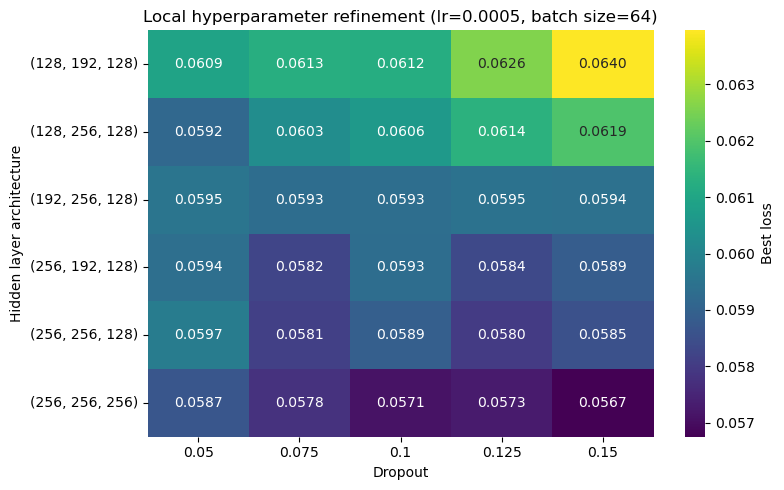

In [86]:
df2_slice = df2_plot[
    (df2_plot["learning_rate"] == best_lr) &
    (df2_plot["batch_size"] == best_bs)
]

pivot2 = df2_slice.pivot_table(
    values="best_loss",
    index="hidden_label",
    columns="dropout",
    aggfunc="min"
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot2,
    annot=True,
    fmt=".4f",
    cmap="viridis",
    cbar_kws={"label": "Best loss"}
)
plt.xlabel("Dropout")
plt.ylabel("Hidden layer architecture")
plt.title(f"Local hyperparameter refinement (lr={best_lr}, batch size={best_bs})")
plt.tight_layout()
plt.show()

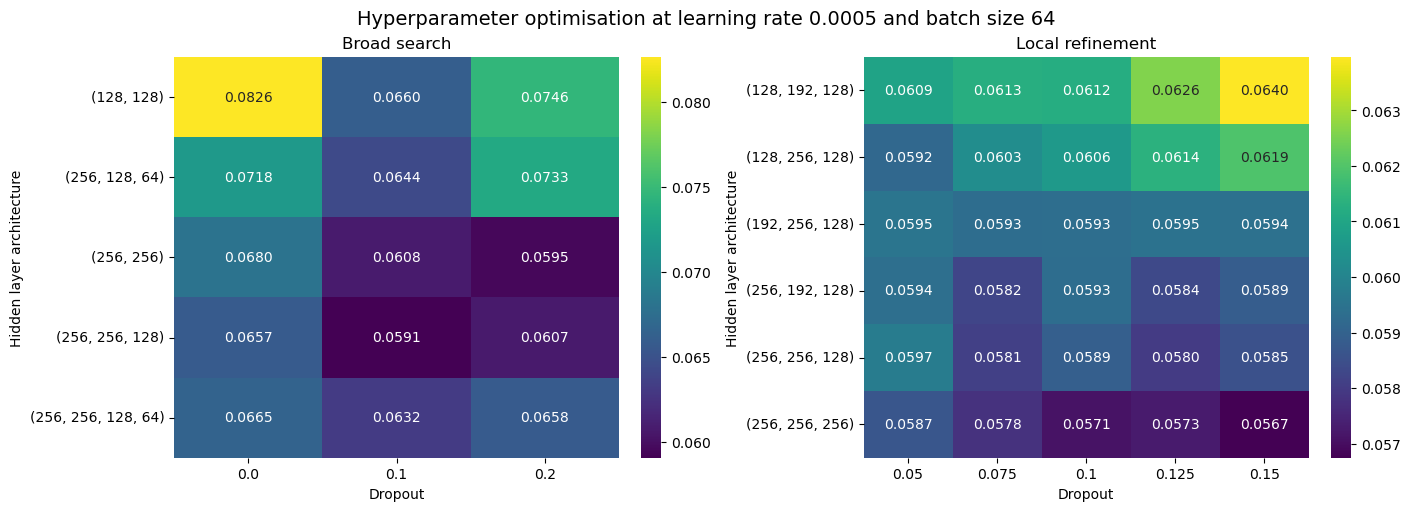

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.heatmap(
    pivot1,
    annot=True,
    fmt=".4f",
    cmap="viridis",
    cbar=True,
    ax=axes[0]
)
axes[0].set_xlabel("Dropout")
axes[0].set_ylabel("Hidden layer architecture")
axes[0].set_title("Broad search")

sns.heatmap(
    pivot2,
    annot=True,
    fmt=".4f",
    cmap="viridis",
    cbar=True,
    ax=axes[1]
)
axes[1].set_xlabel("Dropout")
axes[1].set_ylabel("Hidden layer architecture")
axes[1].set_title("Local refinement")

fig.suptitle(f"Hyperparameter optimisation at learning rate {best_lr} and batch size {best_bs}", fontsize=14)
plt.show()

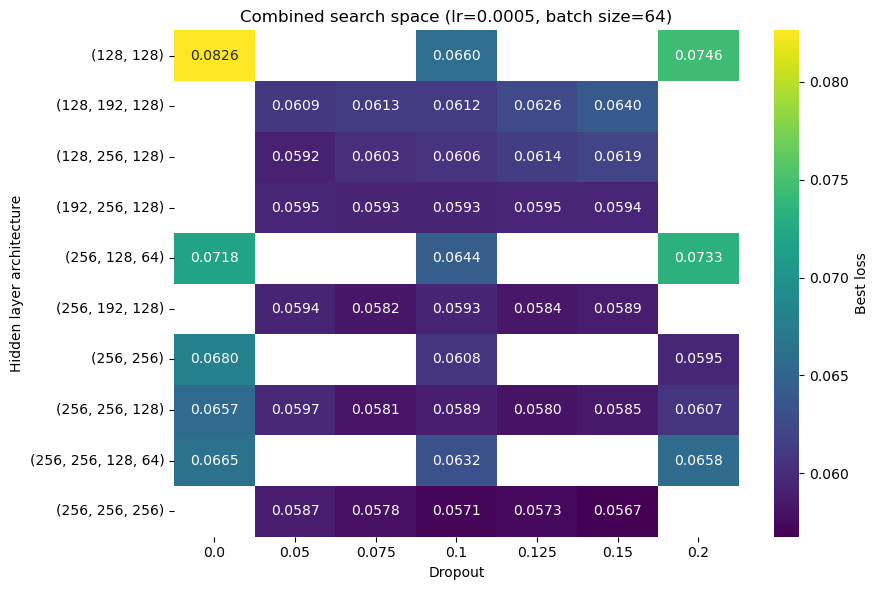

In [88]:
df_all_slice = df_all_plot[
    (df_all_plot["learning_rate"] == best_lr) &
    (df_all_plot["batch_size"] == best_bs)
]

pivot_all = df_all_slice.pivot_table(
    values="best_loss",
    index="hidden_label",
    columns="dropout",
    aggfunc="min"
)

plt.figure(figsize=(9, 6))
sns.heatmap(
    pivot_all,
    annot=True,
    fmt=".4f",
    cmap="viridis",
    cbar_kws={"label": "Best loss"}
)
plt.xlabel("Dropout")
plt.ylabel("Hidden layer architecture")
plt.title(f"Combined search space (lr={best_lr}, batch size={best_bs})")
plt.tight_layout()
plt.show()

In [89]:
import numpy as np
import matplotlib.pyplot as plt
import QST_core_processes as qst

MAX_EPOCHS = 300

final_model = qst.NN_Builder(
    n_qubits=2,
    model_type="mlp",
    loss_type="fidelity",
    target="tau",
    hidden_sizes=(256, 256, 256),
    dropout=0.08,
    lr=5e-4,
    batch_size=64,
    epochs=MAX_EPOCHS
)

history, _ = final_model.fit_and_predict(data_train, data_val)

print(history.keys())

dict_keys(['loss'])


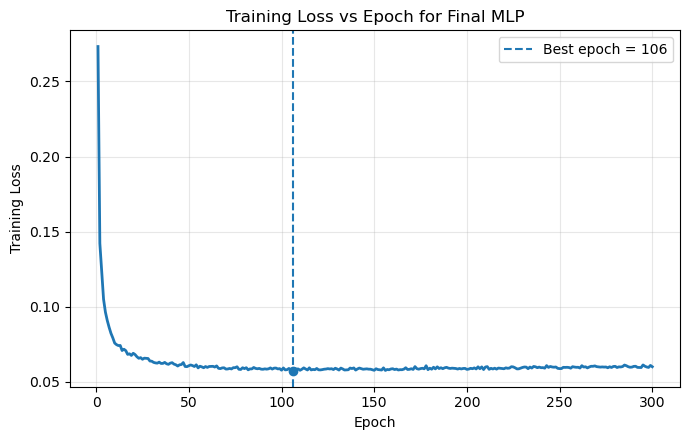

Chosen best epoch: 106
Minimum loss: 0.05750977783463895


In [90]:
# Prefer validation loss if available
if "val_loss" in history:
    losses_to_plot = history["val_loss"]
    loss_label = "Validation Loss"
elif "validation_loss" in history:
    losses_to_plot = history["validation_loss"]
    loss_label = "Validation Loss"
else:
    losses_to_plot = history["loss"]
    loss_label = "Training Loss"

epochs = np.arange(1, len(losses_to_plot) + 1)
best_epoch = np.argmin(losses_to_plot) + 1
best_loss = np.min(losses_to_plot)

plt.figure(figsize=(7, 4.5))
plt.plot(epochs, losses_to_plot, linewidth=2)
plt.axvline(best_epoch, linestyle="--", linewidth=1.5, label=f"Best epoch = {best_epoch}")
plt.scatter(best_epoch, best_loss, zorder=3)

plt.xlabel("Epoch")
plt.ylabel(loss_label)
plt.title(f"{loss_label} vs Epoch for Final MLP")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Chosen best epoch:", best_epoch)
print("Minimum loss:", best_loss)

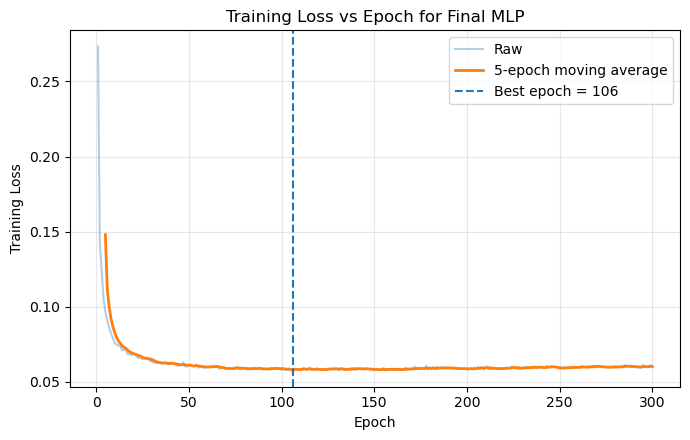

In [91]:
window = 5
smoothed = np.convolve(losses_to_plot, np.ones(window)/window, mode="valid")
smoothed_epochs = np.arange(window, len(losses_to_plot) + 1)

plt.figure(figsize=(7, 4.5))
plt.plot(epochs, losses_to_plot, alpha=0.35, label="Raw")
plt.plot(smoothed_epochs, smoothed, linewidth=2, label=f"{window}-epoch moving average")
plt.axvline(best_epoch, linestyle="--", linewidth=1.5, label=f"Best epoch = {best_epoch}")

plt.xlabel("Epoch")
plt.ylabel(loss_label)
plt.title(f"{loss_label} vs Epoch for Final MLP")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Example save commands
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.heatmap(pivot1, annot=True, fmt=".4f", cmap="viridis", cbar=True, ax=axes[0])
axes[0].set_xlabel("Dropout")
axes[0].set_ylabel("Hidden layer architecture")
axes[0].set_title("Broad search")

sns.heatmap(pivot2, annot=True, fmt=".4f", cmap="viridis", cbar=True, ax=axes[1])
axes[1].set_xlabel("Dropout")
axes[1].set_ylabel("Hidden layer architecture")
axes[1].set_title("Local refinement")

fig.suptitle(f"Hyperparameter optimisation at learning rate {best_lr} and batch size {best_bs}", fontsize=14)
plt.savefig("hyperparameter_heatmaps.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
plt.figure(figsize=(7, 4.5))
plt.plot(epochs, losses_to_plot, linewidth=2)
plt.axvline(best_epoch, linestyle="--", linewidth=1.5, label=f"Best epoch = {best_epoch}")
plt.scatter(best_epoch, best_loss, zorder=3)
plt.xlabel("Epoch")
plt.ylabel(loss_label)
plt.title(f"{loss_label} vs Epoch for Final MLP")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("epoch_validation_curve.png", dpi=300, bbox_inches="tight")
plt.show()